# 05 — Hystérésis sociale : pourquoi un démenti ne suffit pas

C'est le résultat le plus directement actionnable du projet.

En physique, si l'on aimante un morceau de fer puis qu'on coupe le champ, le fer
**reste aimanté**. Il garde une mémoire de son histoire — c'est l'hystérésis.

Transposé : quand une fausse information est massivement diffusée puis officiellement
démentie, le champ médiatique retombe à $H = 0$, mais l'opinion ne revient pas à la
neutralité. Le terme de conformisme $-J \sum s_i s_j$ a pris le relais du champ : le
groupe maintient la croyance par cohésion interne, parce qu'en sortir coûterait à
chacun sa place dans le groupe.

Ce notebook mesure cette mémoire, et teste le seul remède que le modèle autorise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.ising import hysteresis_loop, onsager_critical_temperature
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()
critical = onsager_critical_temperature()

cold = hysteresis_loop(temperature=1.5, steps=21, size=24, sweeps_per_step=60, seed=1)
hot = hysteresis_loop(temperature=3.5, steps=21, size=24, sweeps_per_step=60, seed=1)

for label, loop in [("société froide (T=1.5)", cold), ("société agitée (T=3.5)", hot)]:
    print(f"{label:26s} aire = {loop.area:6.3f}   aimantation rémanente = {loop.remanent_magnetisation:.3f}")

société froide (T=1.5)     aire =  1.171   aimantation rémanente = 0.993
société agitée (T=3.5)     aire =  0.008   aimantation rémanente = 0.062


## Lecture du cycle

Le cycle se parcourt en trois temps, qui sont exactement les trois phases d'une crise
médiatique :

1. **Injection** — un champ $H > 0$ massif aligne la population, même initialement
   neutre.
2. **Démenti** — le champ retombe à $H = 0$. L'aimantation ne suit pas : elle reste
   proche de son maximum. C'est l'**aimantation rémanente**, la fraction de la
   population qui continue de croire.
3. **Contre-champ** — il faut appliquer un $H < 0$ d'amplitude suffisante, le *champ
   coercitif*, pour forcer le basculement inverse.

La conséquence pratique est nette : **le débunking passif ne fonctionne pas.**
Rétablir la neutralité informationnelle laisse la croyance en place. Seule une
contre-information active, utilisant les mêmes canaux et la même intensité que la
rumeur initiale, franchit le seuil coercitif.

In [2]:
temperatures = np.round(np.arange(1.0, 3.61, 0.2), 2)
loops = [
    hysteresis_loop(temperature=float(t), steps=13, size=20, sweeps_per_step=40, seed=2)
    for t in temperatures
]
areas = np.array([loop.area for loop in loops])
remanence = np.array([loop.remanent_magnetisation for loop in loops])

crossing = temperatures[int(np.argmax(remanence < 0.5))]
print(f"la rémanence passe sous 0,5 vers T = {crossing:.1f}  (T_c = {critical:.2f})")

la rémanence passe sous 0,5 vers T = 2.4  (T_c = 2.27)


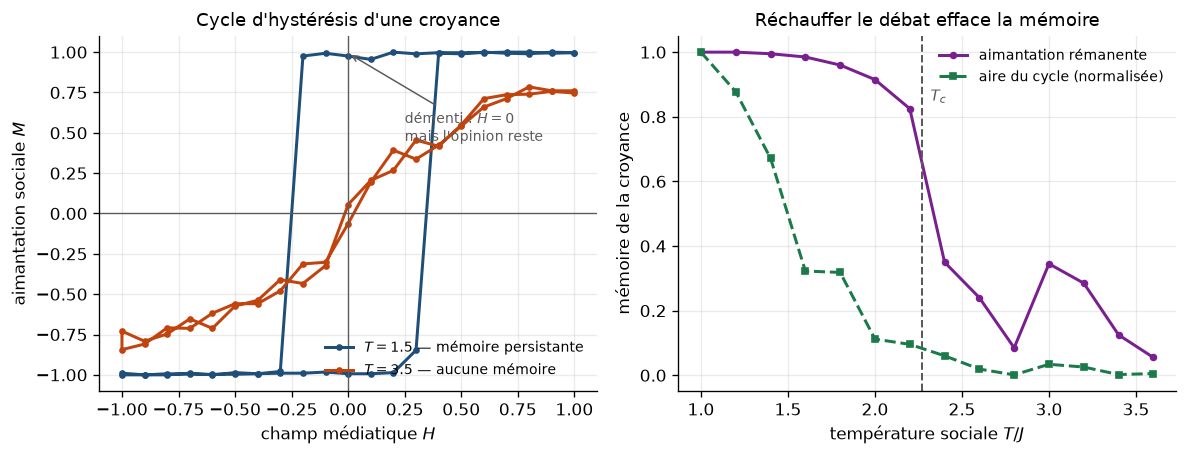

In [3]:
figure, (left, right) = plt.subplots(1, 2, figsize=(10, 3.9))

for loop, colour, label in [
    (cold, PALETTE["order"], f"$T = {cold.temperature}$ — mémoire persistante"),
    (hot, PALETTE["disorder"], f"$T = {hot.temperature}$ — aucune mémoire"),
]:
    left.plot(loop.fields, loop.magnetisations, "o-", color=colour, markersize=3, label=label)

left.axhline(0.0, color=PALETTE["neutral"], linewidth=0.8)
left.axvline(0.0, color=PALETTE["neutral"], linewidth=0.8)
left.annotate(
    "démenti : $H = 0$\nmais l'opinion reste",
    xy=(0.0, cold.remanent_magnetisation),
    xytext=(0.25, 0.45),
    fontsize=8.5,
    color=PALETTE["neutral"],
    arrowprops=dict(arrowstyle="->", color=PALETTE["neutral"], linewidth=0.9),
)
left.set_xlabel("champ médiatique $H$")
left.set_ylabel("aimantation sociale $M$")
left.set_title("Cycle d'hystérésis d'une croyance")
left.legend(fontsize=8.5, loc="lower right")

right.plot(temperatures, remanence, "o-", color=PALETTE["field"], markersize=3.5,
           label="aimantation rémanente")
right.plot(temperatures, areas / areas.max(), "s--", color=PALETTE["remedy"], markersize=3.5,
           label="aire du cycle (normalisée)")
right.axvline(critical, color=PALETTE["neutral"], linestyle="--", linewidth=1.2)
right.text(critical + 0.05, 0.85, r"$T_c$", color=PALETTE["neutral"], fontsize=9)
right.set_xlabel("température sociale $T / J$")
right.set_ylabel("mémoire de la croyance")
right.set_title("Réchauffer le débat efface la mémoire")
right.legend(fontsize=8.5)

save_figure(figure, "fig05_hysteresis.png")
plt.show()

## Ce que le notebook établit

1. Sous $T_c$, l'aire du cycle est strictement positive et la rémanence dépasse 0,8 :
   la croyance survit intégralement au démenti. Au-dessus, le cycle se referme et la
   mémoire disparaît.
2. La mémoire décroît de façon monotone avec la température sociale jusqu'au
   voisinage de $T_c$. **Réchauffer le débat dissipe l'hystérésis** — c'est le
   fondement de la recommandation d'injection de bruit thermique.
3. Deux leviers distincts en découlent, et ils ne s'excluent pas : agir sur $T$
   (diversité informationnelle, structurel, lent) ou appliquer un contre-champ $-H$
   (contre-discours ciblé, conjoncturel, coûteux).